In [1]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import sparrow as sp
from sparrow.io._visium_hd import visium_hd
import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import _rasterize_bins from ../scripts/utils
import sys
sys.path.append('../scripts')
from utils import _rasterize_bins

/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/chananchidas/miniconda3/envs/napari-sparrow/lib/python3.10/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribut

In this notebook, we are going to preprocess the 2um bin size according to the single-cell analysis pipeline. (Due to the computational load, we are not really able to do this.)

In [ ]:
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.n_jobs = 8
sc.settings.verbosity = 3

In [ ]:
sdata = sd.read_zarr('../data/Visium_HD_Liver/Visium_HD_Liver_zarr')

## QC and preprocessing

We perform some basic filtering of spots based on total counts and expressed genes on the 2um bin

In [ ]:
adata = sdata['square_002um']
adata

AnnData object with n_obs × n_vars = 7375079 × 19059
    obs: 'cell_ID', 'in_tissue', 'array_row', 'array_col', 'fov_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

In [ ]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

Text(0, 0.5, '')

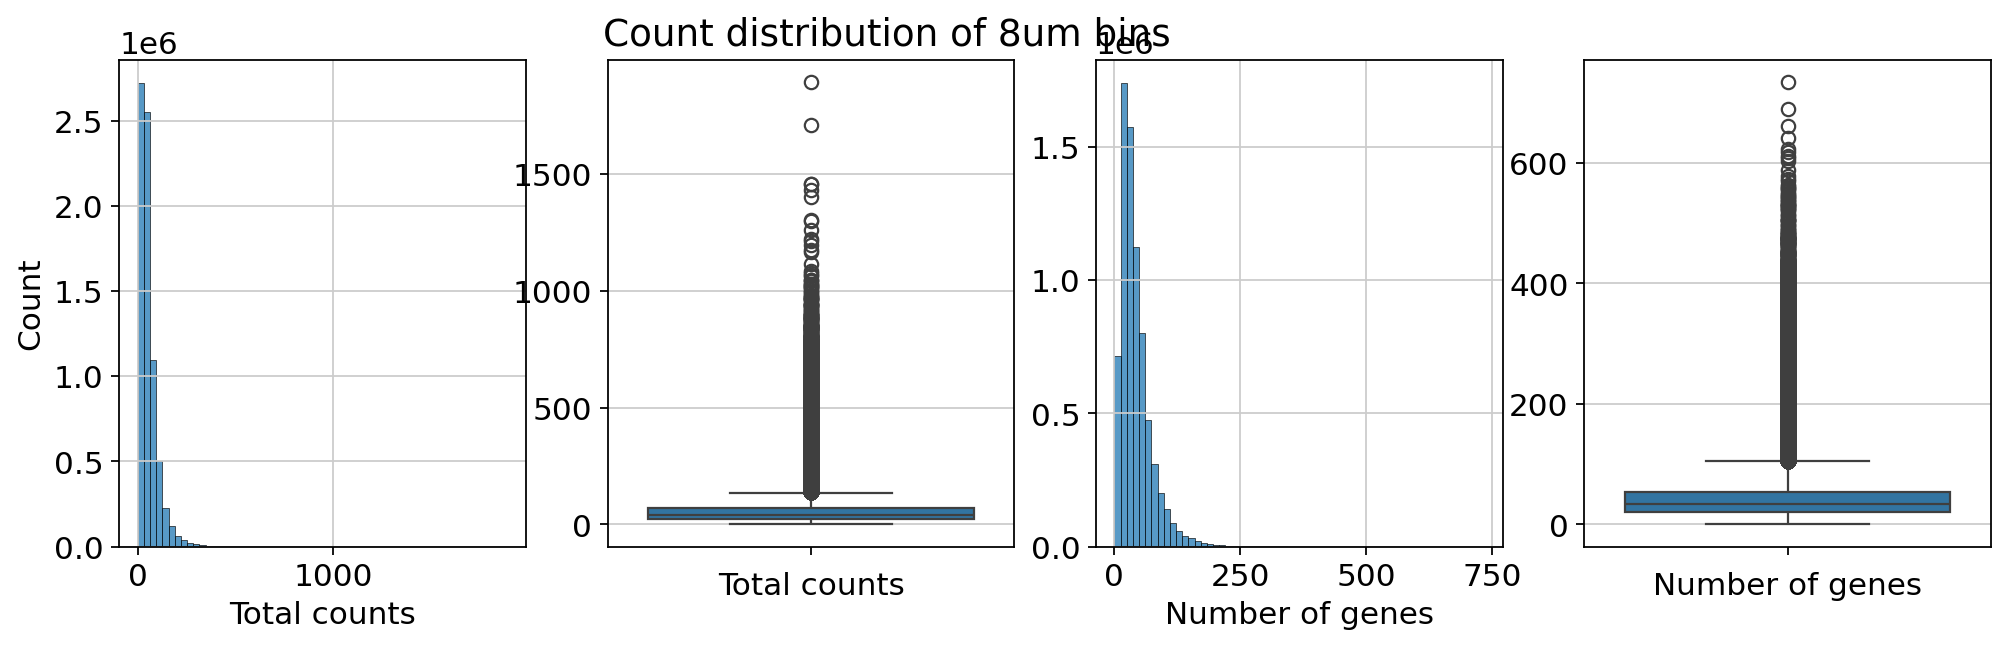

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, bins=60, ax=axs[0])
sns.boxplot(adata.obs["total_counts"], ax=axs[1])

sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
sns.boxplot(adata.obs["n_genes_by_counts"], ax=axs[3])

# Set overall title
fig.suptitle("Count distribution of 2um bins")

# Set title and labels
axs[0].set_xlabel("Total counts")
axs[1].set_xlabel("Total counts")
axs[2].set_xlabel("Number of genes")
axs[3].set_xlabel("Number of genes")

# Turn off y-axis title
axs[1].set_ylabel("")
axs[2].set_ylabel("")
axs[3].set_ylabel("")


In [9]:
#sc.pp.filter_cells(adata, min_counts=50)
sc.pp.filter_cells(adata, max_counts=1500)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(f"#cells after MT filter: {adata.n_obs}")
sc.pp.filter_genes(adata, min_cells=10)

filtered out 2 cells that have more than 1500 counts
#cells after MT filter: 7370185
filtered out 1468 genes that are detected in less than 10 cells


We proceed to normalize Visium counts data with the built-in `normalize_total` method from Scanpy, and detect highly-variable genes (for later). Note that there are alternatives for normalization (see discussion in [[Luecken19](https://www.embopress.org/doi/full/10.15252/msb.20188746)], and more recent alternatives such as [SCTransform](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1874-1) or [GLM-PCA](https://genomebiology.biomedcentral.com/articles/10.1186/s13059-019-1861-6)).

In [10]:
adata.layers["counts"] = adata.X.copy()

In [11]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

normalizing counts per cell
    finished (0:00:01)
extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [12]:
# Save adata as pp
sdata.tables["square_002um_pp"] = adata
sdata.write_element("square_002um_pp")

## Manifold embedding and clustering based on transcriptional similarity

### Stopped here because of the memory limit.

To embed and cluster the manifold encoded by transcriptional similarity, we proceed as in the standard clustering tutorial.

In [13]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)

computing PCA
    with n_comps=50
    finished (0:00:38)
computing neighbors
    using 'X_pca' with n_pcs = 50


: 

In [ ]:
sc.tl.umap(adata)
sc.tl.leiden(
    adata, key_added="clusters", flavor="igraph", directed=False, n_iterations=2
)

computing PCA
    with n_comps=50
    finished (0:00:03)
computing neighbors
    using 'X_pca' with n_pcs = 50


/home/chananchidas/miniconda3/envs/harpy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:24)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:01:44)
running Leiden clustering
    finished: found 9 clusters and added
    'clusters', the cluster labels (adata.obs, categorical) (0:00:06)


We plot some covariates to check if there is any particular structure in the UMAP associated with total counts and detected genes.

In [ ]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

In [ ]:
# Plot some liver zonation markers
zonation_markers = ['Glul', 'Hal']
sc.pl.umap(adata, color=zonation_markers, wspace=0.4)